# 01 EDA - Email Dataset Tribe EC&A

This notebook explores the cleaned email dataset before labeling and modeling.  
The goal is to understand the dataset structure, duplicate behavior, temporal coverage, sender concentration, thread patterns, and text length distributions

Each chart is preceded by a short comment explaining what the graph is intended to show and which patterns are worth checking.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)
plt.style.use('default')

DATA_DIR = Path('../data') if Path('../data').exists() else Path('data')
RAW_PATH = DATA_DIR / 'data.parquet'
TRAIN_PATH = DATA_DIR / 'train.parquet'
TEST_PATH = DATA_DIR / 'test.parquet'
DATASET_PATH = DATA_DIR / 'dataset.parquet'
GOLD_PATH = DATA_DIR / 'gold_labels.parquet'

In [5]:
raw = pd.read_parquet("../data/data.parquet")

train = pd.read_parquet("../data/train.parquet")
test = pd.read_parquet("../data/test.parquet")
clean = pd.concat([train, test], ignore_index=True)
clean['duplicate'] = 0

clean

,id,message_id,date,sender,to,cc,bcc,subject,body,x_from,x_to,x_cc,x_bcc,x_folder,x_origin,x_filename,source_file,thread_id,parent_id,sequence,is_forward,is_reply,sender_domain,recipient_domain,gold_labels,duplicate
0,109782,<5514598.1075862425400.JavaMail.evans@thyme>,2001-11-07 15:49:19+00:00,lindy.donoho@enron.com,[kathy.campos@enron.com],[tracy.geaccone@enron.com],[tracy.geaccone@enron.com],spreadsheet for mtg this morning,"Please print a few copies of this spreadsheet and take them to Tracy in her meeting this morning.\n\nThanks,\nLindy\...","Donoho, Lindy </O=ENRON/OU=NA/CN=RECIPIENTS/CN=LDONOHO>","Campos, Kathy </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Kcampos>","Geaccone, Tracy </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Tgeacco>",,"\TGEACCO (Non-Privileged)\Geaccone, Tracy\Inbox",Geaccone-T,TGEACCO (Non-Privileged).pst,data/extracted/maildir/geaccone-t/inbox/446.,0049263cdf374df3a0b8353d6fc573d12aa09842389bf0ffed9f5a8cea3176b9,NaN,1,False,False,enron.com,[enron.com],NaN,0
1,206201,<16813213.1075846930667.JavaMail.evans@thyme>,2000-02-17 17:50:00+00:00,molly.harris@enron.com,"[frank.davis@enron.com, karen.lambert@enron.com, samuel.schott@enron.com, tana.jones@enron.com]","[bernice.rodriguez@enron.com, bhautik.patel@enron.com, brant.reves@enron.com, brian.hunter-lindsay@enron.com, carrie...","[bernice.rodriguez@enron.com, bhautik.patel@enron.com, brant.reves@enron.com, brian.hunter-lindsay@enron.com, carrie...",eol credit responses 2/17,Please find attached Credit's EOL responses for 2/17/00.\n\n\n\nRegards\nMolly,Molly Harris,"Frank L Davis, Karen Lambert, Tana Jones, Samuel Schott","Sheri Thomas, Mark Taylor, Bernice Rodriguez, Tom Moran, Brant Reves, Debbie R Brackett, Brian Hunter-Lindsay, Coenr...",,\Tanya_Jones_Dec2000\Notes Folders\All documents,JONES-T,tjones.nsf,data/extracted/maildir/jones-t/all_documents/864.,0049fe1c4b318dc877e04a5635d4d217f2a55ab0ea578ef785c511d79c187381,NaN,1,False,False,enron.com,[enron.com],NaN,0
2,167049,<19985894.1075841997166.JavaMail.evans@thyme>,2001-06-26 23:35:31+00:00,rumaldo.lopez@enron.com,None,None,None,it meeting,\n\n--------- Inline attachment follows ---------\n\nFrom: \nDate: ????????????????????????????????????????????????...,"Lopez, Rumaldo </O=ENRON/OU=NA/CN=RECIPIENTS/CN=RLOPEZ3>",,,,"\ExMerge - White, Stacey W.\Calendar",WHITE-S,stacy white 7-15-02.PST,data/extracted/maildir/white-s/calendar/144.,004a50081901a54101f96e52dae9c5ea5cbf24f406e144f5d9bbd5af7489b845,NaN,1,False,False,enron.com,[],NaN,0
3,50285,<2204368.1075847959885.JavaMail.evans@thyme>,2001-02-14 04:10:00+00:00,sgovenar@govadv.com,"[acomnes@enron.com, beverly.aden@enron.com, bhansen@lhom.com, bill.votaw@enron.com, carol.moffett@enron.com, ccalger...",None,None,direct access,Two different sources have heard that Governor Davis is preparing to\norder the CPUC to implement the provision in A...,Scott Govenar <sgovenar@govadv.com>,"Hedy Govenar <hgovenar@govadv.com>, Mike Day <MDay@GMSSR.com>, Bev Hansen <bhansen@lhom.com>, Jeff Dasovich <jdasovi...",,,\Steven_Kean_June2001_3\Notes Folders\Calendar\Untitled,KEAN-S,skean.nsf,data/extracted/maildir/kean-s/calendar/untitled/7474.,004a7cff7597737564b8e22ac09e90d5202ac531f8fc155dddf9187c0b528644,NaN,1,False,False,govadv.com,"[enron.com, gmssr.com, govadv.com, lhom.com]",NaN,0
4,212696,<32367688.1075847028270.JavaMail.evans@thyme>,2000-10-23 11:28:00+00:00,gillian.johnson@enron.com,[tana.jones@enron.com],None,None,i2 technologies,---------------------- Forwarded by Gillian Johnson/NA/Enron on 10/23/2000 \n11:28 AM ---------------------------\n\...,Gillian Johnson,Tana Jones,,,\Tanya_Jones_Dec2000\Notes Folders\All documents,JONES-T,tjones.nsf,data/extracted/maildir/jones-t/all_documents/4683.,004ade473ceeffea6bf4b6773cf7e6a08f91abfcfb857dd27f08bd120dfa66d0,NaN,1,False,True,enron.com,[enron.com],NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129798,182888,<3410869.1075852334337.JavaMail.evans@thyme>,2001-10-25 15:49:43

In [71]:
df = raw.merge(clean[['message_id', 'duplicate']], how='left', on='message_id')
df['duplicate'] = df['duplicate'].fillna(1).astype(int)
df['folder'] = df['x_folder'].str.split('\\').str[-1]

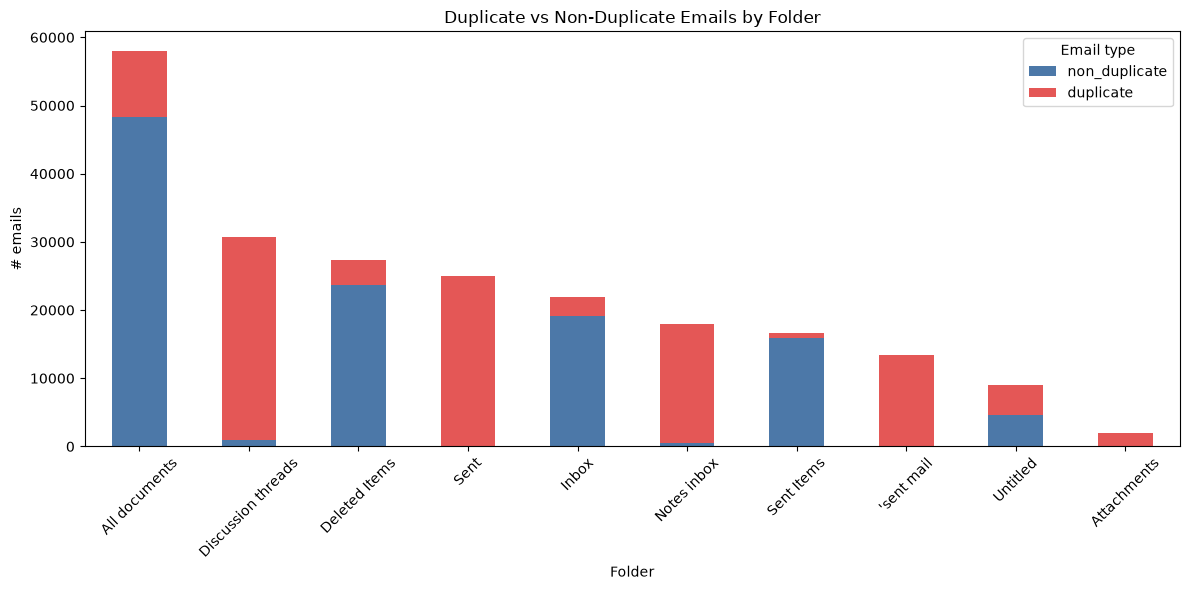

In [72]:
# stacked bar chart: duplicate vs non-duplicate for top 10 folders by total emails

plot_df = (
    df.groupby(["folder", "duplicate"])
    .size()
    .unstack(fill_value=0)
)

plot_df = plot_df.rename(columns={0: "non_duplicate", 1: "duplicate"})

for col in ["non_duplicate", "duplicate"]:
    if col not in plot_df.columns:
        plot_df[col] = 0

plot_df["total"] = plot_df["non_duplicate"] + plot_df["duplicate"]

plot_df = (
    plot_df.sort_values("total", ascending=False)
    .head(10)
    [["non_duplicate", "duplicate"]]
)

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#4C78A8", "#E45756"],
)

ax.set_title("Duplicate vs Non-Duplicate Emails by Folder")
ax.set_xlabel("Folder")
ax.set_ylabel("# emails")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Email type")

plt.tight_layout()
plt.show()

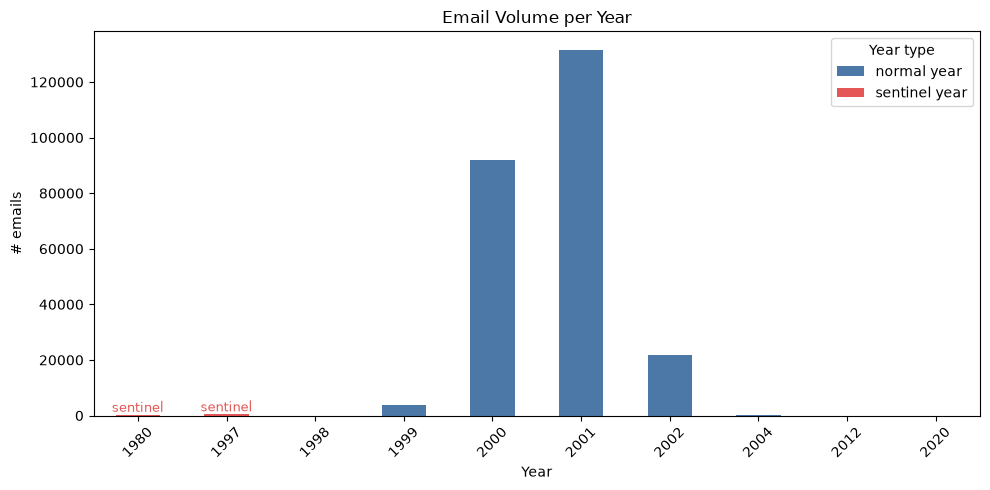

In [73]:
# email volume per year with sentinel years highlighted

sentinel_years = [1980, 1997]

year_counts = df.groupby(df["date"].dt.year).size().rename("emails")

is_sentinel = year_counts.index.isin(sentinel_years)

colors = ["#E45756" if sentinel else "#4C78A8" for sentinel in is_sentinel]

ax = year_counts.plot(
    kind="bar",
    figsize=(10, 5),
    color=colors,
)

ax.set_title("Email Volume per Year")
ax.set_xlabel("Year")
ax.set_ylabel("# emails")
ax.tick_params(axis="x", rotation=45)

for i, (year, count) in enumerate(year_counts.items()):
    if year in sentinel_years:
        ax.text(
            i,
            count,
            "sentinel",
            ha="center",
            va="bottom",
            color="#E45756",
            fontsize=9,
        )

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor="#4C78A8", label="normal year"),
        Patch(facecolor="#E45756", label="sentinel year"),
    ],
    title="Year type",
)

plt.tight_layout()
plt.show()

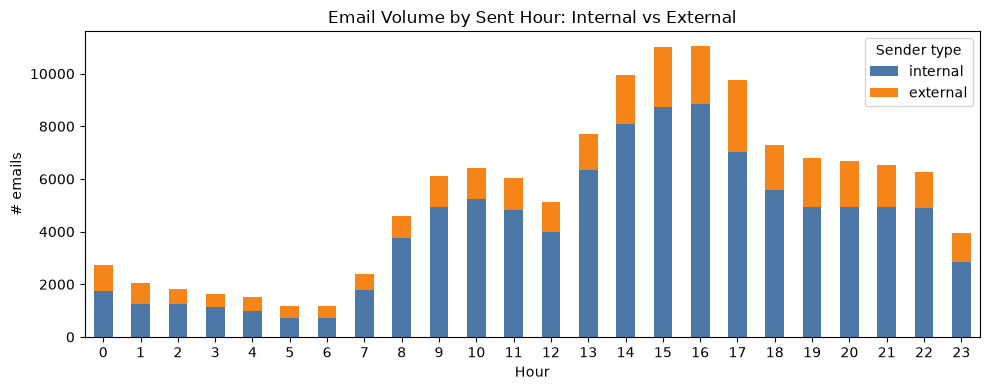

In [99]:
# stacked bar chart: hourly pattern by internal vs external sender

df = clean.copy()

if "sent_hour" not in df.columns and "date" in df.columns:
    df["sent_hour"] = df["date"].dt.hour

if "sender_domain" not in df.columns:
    df["sender_domain"] = df["sender"].str.extract(r"@(.+)$", expand=False)

df["sender_type"] = df["sender_domain"].eq("enron.com").map(
    {True: "internal", False: "external"}
)

hour_sender = (
    df.groupby(["sent_hour", "sender_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)

ax = hour_sender[["internal", "external"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 4),
    color=["#4C78A8", "#F58518"],
)

ax.set_title("Email Volume by Sent Hour: Internal vs External")
ax.set_xlabel("Hour")
ax.set_ylabel("# emails")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Sender type")

plt.tight_layout()
plt.show()

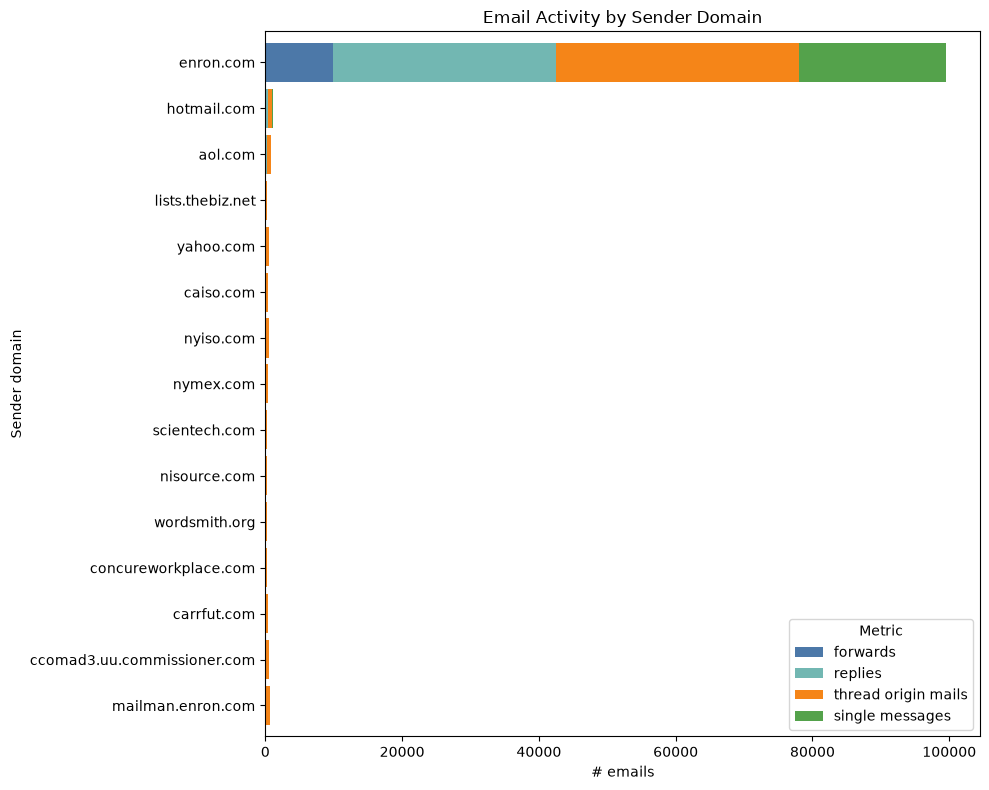

In [100]:
# stacked horizontal bar chart: forwards, replies, thread origin mails, and single messages per sender domain

df = clean.copy()

plot_df = (
    df.groupby("sender_domain")
    .agg(
        forwards=("is_forward", "sum"),
        replies=("is_reply", "sum"),
        threads=("thread_id", "nunique"),
        messages=("message_id", "nunique"),
    )
)

plot_df["thread_origin_mails"] = (
    plot_df["threads"] - plot_df["replies"] - plot_df["forwards"]
).clip(lower=0)

plot_df["single_messages"] = plot_df["messages"] - plot_df["threads"]

plot_df = plot_df[["forwards", "replies", "thread_origin_mails", "single_messages"]]

top_domains = (
    plot_df.sum(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

plot_df = plot_df.loc[top_domains].sort_values("single_messages", ascending=True)

colors = ["#4C78A8", "#72B7B2", "#F58518", "#54A24B"]

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 8),
    width=0.85,
    color=colors,
)

ax.set_title("Email Activity by Sender Domain")
ax.set_xlabel("# emails")
ax.set_ylabel("Sender domain")
ax.legend(
    title="Metric",
    labels=["forwards", "replies", "thread origin mails", "single messages"],
    loc="lower right",
)

plt.tight_layout()
plt.show()

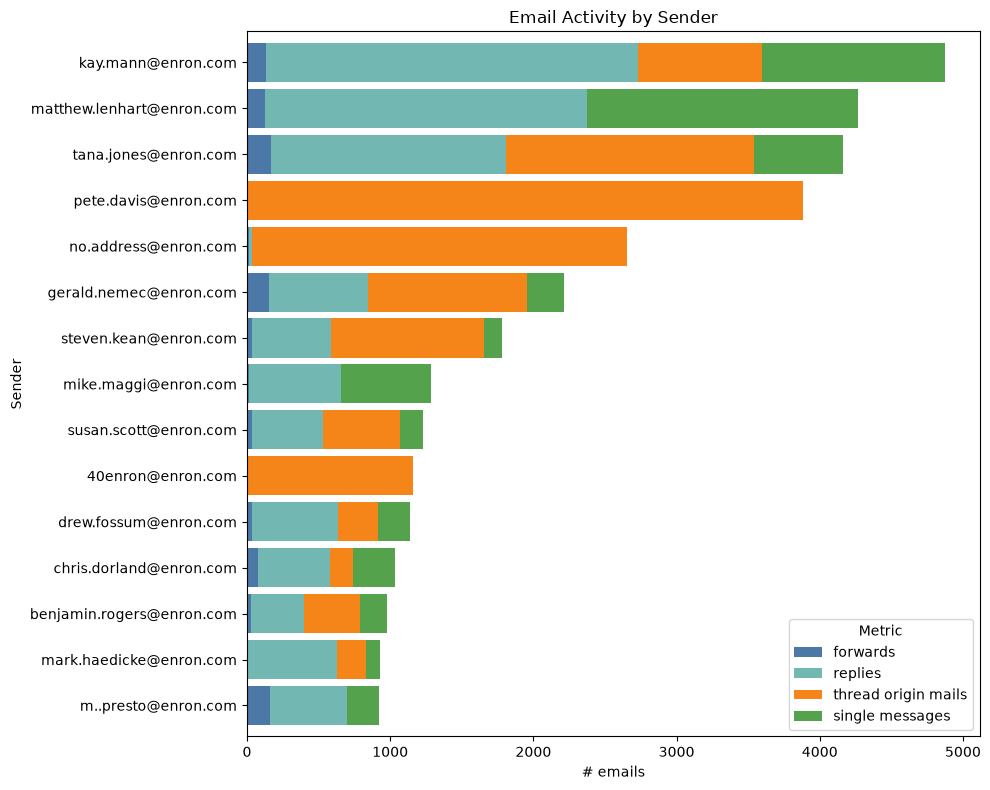

In [101]:
# stacked horizontal bar chart sorted by total volume

df = clean.copy()

plot_df = (
    df.groupby("sender")
    .agg(
        forwards=("is_forward", "sum"),
        replies=("is_reply", "sum"),
        threads=("thread_id", "nunique"),
        messages=("message_id", "nunique"),
    )
)

plot_df["thread_origin_mails"] = (
    plot_df["threads"] - plot_df["replies"] - plot_df["forwards"]
).clip(lower=0)

plot_df["single_messages"] = plot_df["messages"] - plot_df["threads"]

plot_df = plot_df[["forwards", "replies", "thread_origin_mails", "single_messages"]]
plot_df["total_volume"] = plot_df.sum(axis=1)

plot_df = (
    plot_df.sort_values("total_volume", ascending=False)
    .head(15)
    .sort_values("total_volume", ascending=True)
)

plot_df = plot_df.drop(columns="total_volume")

colors = ["#4C78A8", "#72B7B2", "#F58518", "#54A24B"]

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 8),
    width=0.85,
    color=colors,
)

ax.set_title("Email Activity by Sender")
ax.set_xlabel("# emails")
ax.set_ylabel("Sender")
ax.legend(
    title="Metric",
    labels=["forwards", "replies", "thread origin mails", "single messages"],
    loc="lower right",
)

plt.tight_layout()
plt.show()

In [117]:
# Compute text length features for EDA if they are not already present.
if 'body' in df.columns:
    df['body_chars'] = df['body'].fillna('').astype(str).str.len()
    df['body_words_eda'] = df['body'].fillna('').astype(str).str.count(r'\S+')
if 'subject' in df.columns:
    df['subject_chars'] = df['subject'].fillna('').astype(str).str.len()

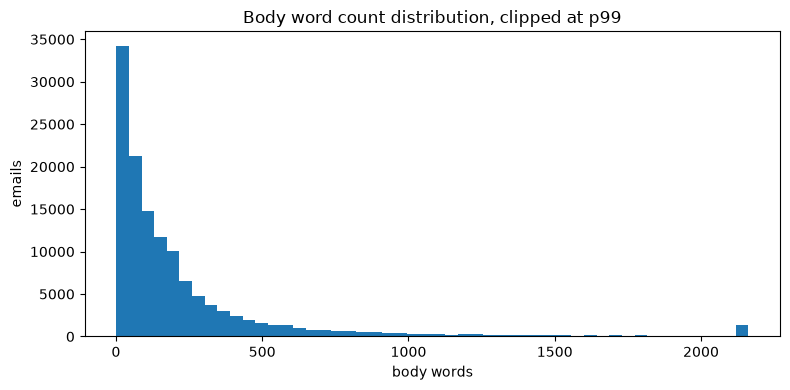

In [118]:
# Graph should show heavy-tailed body length and identify extreme long emails.
if 'body_words_eda' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    df['body_words_eda'].clip(upper=df['body_words_eda'].quantile(0.99)).plot(kind='hist', bins=50, ax=ax)
    ax.set_title('Body word count distribution, clipped at p99')
    ax.set_xlabel('body words')
    ax.set_ylabel('emails')
    plt.tight_layout()
    plt.show()
    df[['message_id', 'subject', 'body_words_eda', 'body_chars']].sort_values('body_chars', ascending=False).head(10)

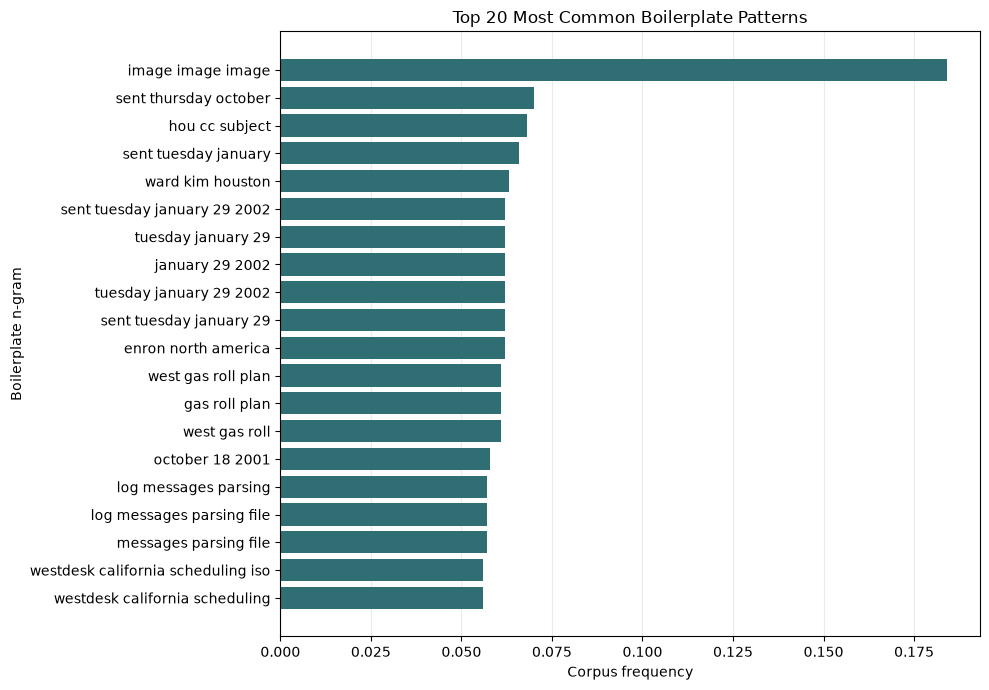

In [6]:
BOILERPLATE_PATH = Path("../lexicon/preprocess/boilerplate.csv")
if not BOILERPLATE_PATH.exists():
    BOILERPLATE_PATH = Path("lexicon/preprocess/boilerplate.csv")

top_n = 20

boilerplate = (
    pd.read_csv(BOILERPLATE_PATH)
    .sort_values("count", ascending=False)
    .head(top_n)
    .sort_values("count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    boilerplate["ngram"],
    boilerplate["count"],
    color="#2f6f73",
)

ax.set_title(f"Top {top_n} Most Common Boilerplate Patterns")
ax.set_xlabel("Corpus frequency")
ax.set_ylabel("Boilerplate n-gram")

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Loaded 21 signature phrases


C:\Windows\Temp\ipykernel_21604\1527524109.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = bodies.str.contains(pattern, regex=True, na=False).sum()


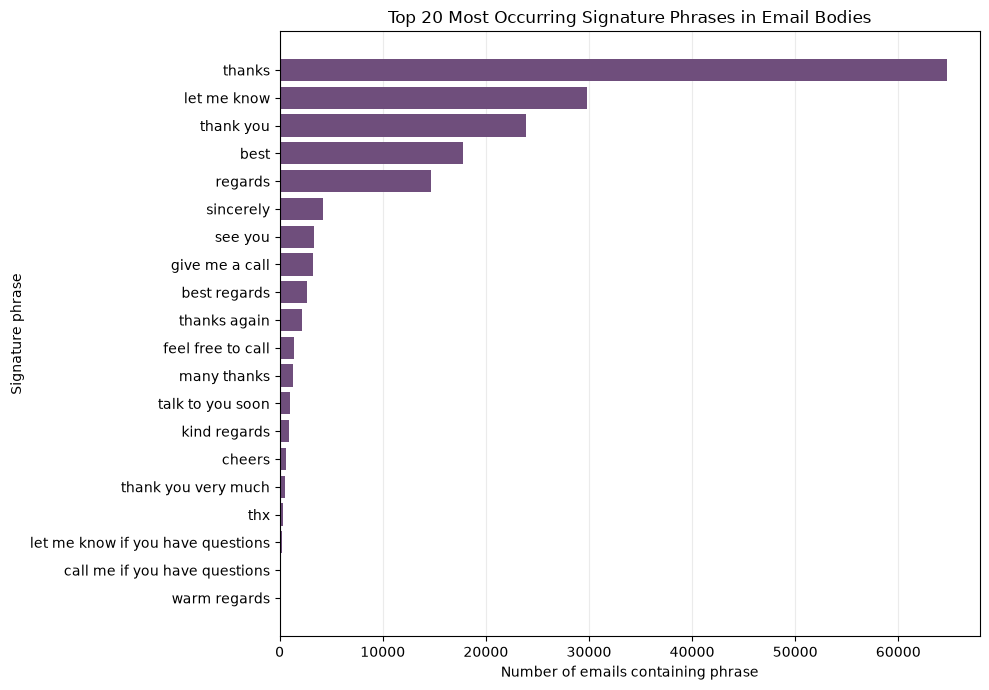

In [13]:
import re

SIGNATURE_PATH = Path("../lexicon/preprocess/signature.csv")
if not SIGNATURE_PATH.exists():
    SIGNATURE_PATH = Path("lexicon/preprocess/signature.csv")

DATA_PATH = Path("../data/data.parquet")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/data.parquet")

raw_signatures = pd.read_csv(
    SIGNATURE_PATH,
    header=None,
    dtype=str,
    keep_default_na=False,
)

signatures = (
    raw_signatures.iloc[:, 0]
    .astype(str)
    .str.strip()
    .str.lower()
)

signatures = signatures[
    signatures.ne("")
    & ~signatures.isin(["nan", "none", "signature"])
].drop_duplicates()

print(f"Loaded {len(signatures)} signature phrases")

emails = pd.read_parquet(DATA_PATH, columns=["body"])
bodies = emails["body"].fillna("").astype(str).str.lower()

rows = []
for phrase in signatures:
    pattern = rf"(^|\n|\r|\s){re.escape(phrase)}(\s|,|\.|!|\?|$)"
    count = bodies.str.contains(pattern, regex=True, na=False).sum()
    rows.append({"signature": phrase, "count": int(count)})

signature_counts = pd.DataFrame(rows, columns=["signature", "count"])

signature_counts = (
    signature_counts[signature_counts["count"] > 0]
    .sort_values("count", ascending=False)
    .head(20)
    .sort_values("count", ascending=True)
)

if signature_counts.empty:
    print("No signature phrases were found in the email bodies.")
else:
    fig, ax = plt.subplots(figsize=(10, 7))

    ax.barh(
        signature_counts["signature"],
        signature_counts["count"],
        color="#6f4e7c",
    )

    ax.set_title("Top 20 Most Occurring Signature Phrases in Email Bodies")
    ax.set_xlabel("Number of emails containing phrase")
    ax.set_ylabel("Signature phrase")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()